In [ ]:
from google.colab import drive

# This will prompt a popup asking for permission to access your Drive
drive.mount('/content/drive')

# Create a folder for your project if it doesn't exist
import os
os.makedirs('/content/drive/MyDrive/DataMiningProject', exist_ok=True)
print("Drive mounted and folder ready!")

Mounted at /content/drive
Drive mounted and folder ready!


In [ ]:
from google.colab import auth

# This will open another popup to verify your Google account
auth.authenticate_user()
print("Authenticated successfully!")

Authenticated successfully!


In [ ]:
from google.cloud import bigquery
import pandas as pd

# 1. Initialize the BigQuery Client
project_id = 'data-mining-github'
client = bigquery.Client(project=project_id)

# 2. Write your SQL Query
# Note: We are limiting to 1000 rows just to test the pipeline first.
sql_query = """
    SELECT
        repo.name as repo_name,
        type as event_type,
        created_at,
        actor.login as actor_name
    FROM `githubarchive.day.20230101`
    WHERE type IN ('PushEvent', 'IssuesEvent', 'PullRequestEvent')
    LIMIT 1000
"""

print("Running query... (this might take a few seconds)")

# 3. Execute the query and convert to a Pandas DataFrame
query_job = client.query(sql_query)
df_raw = query_job.to_dataframe()

print(f"Success! Downloaded {len(df_raw)} rows.")

# 4. Save the raw data to Google Drive
# We are using Parquet instead of CSV because it is much faster and smaller
file_path = '/content/drive/MyDrive/DataMiningProject/raw_github_sample.parquet'
df_raw.to_parquet(file_path, index=False)

print(f"Raw data saved to: {file_path}")

# Display the first 5 rows to verify
df_raw.head()

Running query... (this might take a few seconds)
Success! Downloaded 1000 rows.
Raw data saved to: /content/drive/MyDrive/DataMiningProject/raw_github_sample.parquet


,repo_name,event_type,created_at,actor_name
0,thraxil/auriga,IssuesEvent,2023-01-01 14:59:34+00:00,thraxil
1,paolomainardi/hugo-lyra,PushEvent,2023-01-01 14:34:30+00:00,paolomainardi
2,petyosi/material-ui,PushEvent,2023-01-01 14:03:53+00:00,petyosi
3,bwbuchanan/ember-resolver,PushEvent,2023-01-01 14:50:47+00:00,bwbuchanan
4,geneshuman/emacs.d,PushEvent,2023-01-01 14:43:18+00:00,geneshuman


In [ ]:
from google.cloud import bigquery
import pandas as pd

# 1. Initialize the Client
project_id = 'data-mining-github'
client = bigquery.Client(project=project_id)

print("Scanning for our 2,000 target repositories... (This will process more data and take a minute or two)")

# 2. The Logic Query
# Note: I updated the year to 2024 to give you more recent data for your project.
sql_query = """
    WITH RepoActivity AS (
        SELECT
            repo.name as repo_name,
            MAX(created_at) as last_active_date,
            COUNT(*) as total_events
        FROM `githubarchive.day.2024*`
        WHERE type IN ('PushEvent', 'IssuesEvent', 'PullRequestEvent')
          -- Filtering out the bot noise immediately
          AND actor.login NOT LIKE '%bot%'
          AND actor.login NOT LIKE '%dependabot%'
        GROUP BY repo.name
        -- Ensuring we only look at established repos, not empty ones
        HAVING total_events > 100
    ),
    LabeledRepos AS (
        SELECT
            repo_name,
            last_active_date,
            total_events,
            CASE
                -- Cutoff: If last activity was before July 1, 2024, it is Abandoned
                WHEN last_active_date < TIMESTAMP('2024-07-01 00:00:00 UTC') THEN 'Abandoned'
                ELSE 'Active'
            END as repo_status
        FROM RepoActivity
    )

    -- Grab exactly 1000 of each to create a perfectly balanced dataset
    (SELECT * FROM LabeledRepos WHERE repo_status = 'Abandoned' LIMIT 1000)
    UNION ALL
    (SELECT * FROM LabeledRepos WHERE repo_status = 'Active' LIMIT 1000)
"""

# 3. Execute and Convert
query_job = client.query(sql_query)
df_targets = query_job.to_dataframe()

print(f"Success! Retrieved {len(df_targets)} target repositories.")

# 4. Save the Target List to Google Drive
file_path = '/content/drive/MyDrive/DataMiningProject/target_repositories.parquet'
df_targets.to_parquet(file_path, index=False)

print(f"Target list safely stored at: {file_path}")

# Display a sample to verify both labels exist
df_targets.sample(10)

Scanning for our 2,000 target repositories... (This will process more data and take a minute or two)
Success! Retrieved 2000 target repositories.
Target list safely stored at: /content/drive/MyDrive/DataMiningProject/target_repositories.parquet


,repo_name,last_active_date,total_events,repo_status
1528,Kathford-IT-Club-KIC/kathcode-2024-superlatives,2024-06-29 02:53:59+00:00,164,Abandoned
4,COMS4156-Eventease/COMS4156-Project,2024-12-04 19:37:07+00:00,135,Active
1848,EDUREXAcademy/Invidux_Frontend,2024-02-29 15:20:44+00:00,252,Abandoned
307,bricee98/Valsci,2024-12-23 22:36:44+00:00,176,Active
277,lsst-ts/rubintv_visualization,2024-12-20 18:39:41+00:00,114,Active
246,Brunomir4nd4/Cod3rsGrowth,2024-08-30 11:25:55+00:00,101,Active
1349,appseed-projects2/cf34d003-a93f-4388-ba3a-dbf0...,2024-01-26 20:22:04+00:00,155,Abandoned
489,mashharuki/ETHOnline2024,2024-09-08 22:22:38+00:00,145,Active
1798,tramoonyane/holbertonschool-AirBnB_clone_v3,2024-04-27 00:05:39+00:00,124,Abandoned
1343,eminsayt/sayt,2024-02-23 00:47:56+00:00,124,Abandoned


In [ ]:
import pandas as pd
from google.cloud import bigquery

# 1. Load the master list of 2000 repos you just saved
target_path = '/content/drive/MyDrive/DataMiningProject/target_repositories.parquet'
df_targets = pd.read_parquet(target_path)

# Extract the names into a Python list
repo_list = df_targets['repo_name'].tolist()

# 2. Format the list for SQL (e.g., "'repo1', 'repo2', 'repo3'")
formatted_repos = ", ".join([f"'{repo}'" for repo in repo_list])

# 3. Initialize the Client
project_id = 'data-mining-github' # Replace with your Project ID
client = bigquery.Client(project=project_id)

print(f"Preparing to extract logs for {len(repo_list)} repositories...")

# 4. The Final Extraction Query
sql_query = f"""
    SELECT
        repo.name as repo_name,
        type as event_type,
        created_at,
        actor.login as actor_name
    FROM `githubarchive.day.2024*`
    WHERE _TABLE_SUFFIX BETWEEN '0101' AND '0331'
      AND repo.name IN ({formatted_repos})
      AND type IN ('PushEvent', 'IssuesEvent', 'PullRequestEvent')
      AND actor.login NOT LIKE '%bot%'
      AND actor.login NOT LIKE '%dependabot%'
"""

print("Running final extraction... (This will take a few minutes)")

# 5. Execute and Convert to Pandas
query_job = client.query(sql_query)
df_final = query_job.to_dataframe()

print(f"Success! Downloaded {len(df_final)} event logs.")

# 6. Save the final raw dataset
final_path = '/content/drive/MyDrive/DataMiningProject/final_raw_dataset.parquet'
df_final.to_parquet(final_path, index=False)

print(f"Final dataset safely stored at: {final_path}")

# Display the first few rows
df_final.head()

Preparing to extract logs for 2000 repositories...
Running final extraction... (This will take a few minutes)
Success! Downloaded 451206 event logs.
Final dataset safely stored at: /content/drive/MyDrive/DataMiningProject/final_raw_dataset.parquet


,repo_name,event_type,created_at,actor_name
0,binary-com/deriv-static-content,PushEvent,2024-01-16 04:54:54+00:00,ashkan-deriv
1,binary-com/deriv-static-content,PushEvent,2024-01-16 04:51:07+00:00,ashkan-deriv
2,binary-com/deriv-static-content,PushEvent,2024-01-16 04:51:47+00:00,ashkan-deriv
3,binary-com/deriv-static-content,PushEvent,2024-01-16 04:53:49+00:00,ashkan-deriv
4,binary-com/deriv-static-content,PushEvent,2024-01-16 04:51:54+00:00,ashkan-deriv


In [ ]:
import pandas as pd

print("Step 1: Loading datasets...")
# Load the datasets we saved earlier
df_targets = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/target_repositories.parquet')
df_events = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/final_raw_dataset.parquet')

print("Step 2: Merging data...")
# Merge the labels (Active/Abandoned) onto the event logs based on 'repo_name'
# Using an 'inner' join ensures we only keep events for repos that have a label
df_merged = pd.merge(df_events, df_targets[['repo_name', 'repo_status']], on='repo_name', how='inner')

print("Step 3: Chronological sorting (Critical for Sequence Mining)...")
# Sequences MUST be in order of time. We sort by Repo Name, then by Timestamp.
df_merged = df_merged.sort_values(by=['repo_name', 'created_at'])

print("Step 4: Feature Engineering & Aggregation...")
# We group the millions of rows by the repository name to calculate project-level metrics
repo_groups = df_merged.groupby('repo_name')

prepared_data = []

for repo_name, group in repo_groups:
    # --- Format 1: Sequence Data (For PrefixSpan) ---
    # Convert the chronological events into a pure list of strings
    event_sequence = group['event_type'].tolist()

    # --- Format 2: Numerical Features (For Classification) ---
    total_events = len(group)
    unique_contributors = group['actor_name'].nunique()
    push_count = (group['event_type'] == 'PushEvent').sum()
    issue_count = (group['event_type'] == 'IssuesEvent').sum()
    pr_count = (group['event_type'] == 'PullRequestEvent').sum()

    # Calculate Ratios (These are highly predictive features)
    # Avoid division by zero by adding a tiny number (1e-5)
    issue_to_push_ratio = issue_count / (push_count + 1e-5)

    # --- Target Label Encoding ---
    # Machine learning needs numbers, not words. Abandoned = 1, Active = 0
    status = group['repo_status'].iloc[0]
    label = 1 if status == 'Abandoned' else 0

    prepared_data.append({
        'repo_name': repo_name,
        'event_sequence': event_sequence,
        'total_events': total_events,
        'unique_contributors': unique_contributors,
        'push_count': push_count,
        'issue_count': issue_count,
        'pr_count': pr_count,
        'issue_to_push_ratio': issue_to_push_ratio,
        'is_abandoned': label
    })

print("Step 5: Finalizing Training Dataset...")
df_training = pd.DataFrame(prepared_data)

# Save this final masterpiece to Drive
training_path = '/content/drive/MyDrive/DataMiningProject/model_training_data.parquet'
df_training.to_parquet(training_path, index=False)

print(f"Data perfectly preprocessed and saved to: {training_path}")

# Display the final structure
df_training.head()

Step 1: Loading datasets...
Step 2: Merging data...
Step 3: Chronological sorting (Critical for Sequence Mining)...
Step 4: Feature Engineering & Aggregation...
Step 5: Finalizing Training Dataset...
Data perfectly preprocessed and saved to: /content/drive/MyDrive/DataMiningProject/model_training_data.parquet


,repo_name,event_sequence,total_events,unique_contributors,push_count,issue_count,pr_count,issue_to_push_ratio,is_abandoned
0,020204FEI/wiki-documents,"[PushEvent, PushEvent, PushEvent, PushEvent, P...",25,1,25,0,0,0.000000,1
1,0install/0install-win,"[PushEvent, PushEvent, PushEvent, PullRequestE...",57,1,53,0,4,0.000000,0
2,101digital/app-studio-widgets,"[PushEvent, PushEvent, PushEvent, PushEvent, P...",58,1,58,0,0,0.000000,0
3,10up/wp-scaffold,"[IssuesEvent, PullRequestEvent, PushEvent, Pus...",85,8,32,22,31,0.687500,0
4,1s22s1/hitokage,"[PushEvent, PushEvent, PushEvent, PushEvent, P...",217,1,88,129,0,1.465909,1


In [ ]:
!pip install prefixspan

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
  Created wheel for prefixspan: filename=prefixspan-0.5.2-py3-none-any.whl size=11215 sha256=15938e884fad6e850240073cf52aeda9174aae061a782ab895b7f97e1be9c7eb
  Stored in directory: /root/.cache/pip/wheels/72/36/65/f9e2bbe4998ab4cdf6e7a015f38bdbb6925301dcf2cce34a88
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=907e6bb18fdfc880ea92210a5b9e3983ce99b6d7c303fa238aec9afb732039fa
  Stored in directory: /root/.cache/pip/wheels/1a/bf/a1/4cee4f7678c68c5875ca89eaccf460593539805c3906722228
  Created wheel for extratools: filename=extratools-0.8.2.1-py3-none-any.whl size=28865 sha256=e801a9b86dabc0844bda2e6492af07351dbde3a6667f8d5d82d4163b1b00460e
  Stored in directory: /root/.cache/pip/wheels/0f/ab/1f/a5cf2e0513d68e4ff783d169add0c94235bddf2bb8f3dcd581
Successfully built prefixspan docopt extratools


In [ ]:
import pandas as pd
from prefixspan import PrefixSpan

print("Loading preprocessed dataset...")
df_training = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/model_training_data.parquet')

# --- THE CORRECTED FIX: Compression Function ---
def compress_and_truncate(seq, max_length=30):
    # Convert NumPy array back to a standard Python list
    seq = list(seq)

    # Check length explicitly to avoid the NumPy ValueError
    if len(seq) == 0:
        return []

    # 1. Compress consecutive duplicates
    compressed = [seq[0]]
    for item in seq[1:]:
        if item != compressed[-1]:
            compressed.append(item)

    # 2. Keep only the final 'max_length' events
    return compressed[-max_length:]

# Apply the fix to our sequences
abandoned_seqs = [compress_and_truncate(seq) for seq in df_training[df_training['is_abandoned'] == 1]['event_sequence'].tolist()]
active_seqs = [compress_and_truncate(seq) for seq in df_training[df_training['is_abandoned'] == 0]['event_sequence'].tolist()]

print(f"Analyzing {len(abandoned_seqs)} Abandoned and {len(active_seqs)} Active repositories...\n")

# Set minimum support (20% threshold)
min_support_abandoned = int(len(abandoned_seqs) * 0.20)
min_support_active = int(len(active_seqs) * 0.20)

print("Mining patterns...")

# Run PrefixSpan
ps_abandoned = PrefixSpan(abandoned_seqs)
patterns_abandoned = ps_abandoned.frequent(min_support_abandoned)

ps_active = PrefixSpan(active_seqs)
patterns_active = ps_active.frequent(min_support_active)

# --- Formatting the Output ---
def print_top_patterns(patterns, title, total_repos):
    print(f"--- Top 5 Patterns for {title} Repositories ---")
    patterns.sort(key=lambda x: x[0], reverse=True)
    sequence_patterns = [p for p in patterns if len(p[1]) > 1]

    for i, (freq, seq) in enumerate(sequence_patterns[:5]):
        percentage = (freq / total_repos) * 100
        seq_str = " -> ".join(seq)
        print(f"{i+1}. {seq_str}")
        print(f"   Support: {freq} repos ({percentage:.1f}%)\n")

print_top_patterns(patterns_abandoned, "ABANDONED", len(abandoned_seqs))
print_top_patterns(patterns_active, "ACTIVE", len(active_seqs))

Loading preprocessed dataset...
Analyzing 727 Abandoned and 502 Active repositories...

Mining patterns...
--- Top 5 Patterns for ABANDONED Repositories ---
1. PushEvent -> PushEvent
   Support: 332 repos (45.7%)

2. PullRequestEvent -> PushEvent
   Support: 307 repos (42.2%)

3. PushEvent -> PullRequestEvent
   Support: 306 repos (42.1%)

4. PushEvent -> PullRequestEvent -> PushEvent
   Support: 305 repos (42.0%)

5. PushEvent -> PushEvent -> PushEvent
   Support: 302 repos (41.5%)

--- Top 5 Patterns for ACTIVE Repositories ---
1. PushEvent -> PushEvent
   Support: 259 repos (51.6%)

2. PullRequestEvent -> PushEvent
   Support: 242 repos (48.2%)

3. PushEvent -> PullRequestEvent
   Support: 240 repos (47.8%)

4. PushEvent -> PushEvent -> PushEvent
   Support: 239 repos (47.6%)

5. PushEvent -> PullRequestEvent -> PushEvent
   Support: 236 repos (47.0%)



Loading raw events for Graph Mining...
Extracting Network Metrics for 2,000 repositories
Metrics extracted successfully!

Generating the Social Graph Visuals for your report...


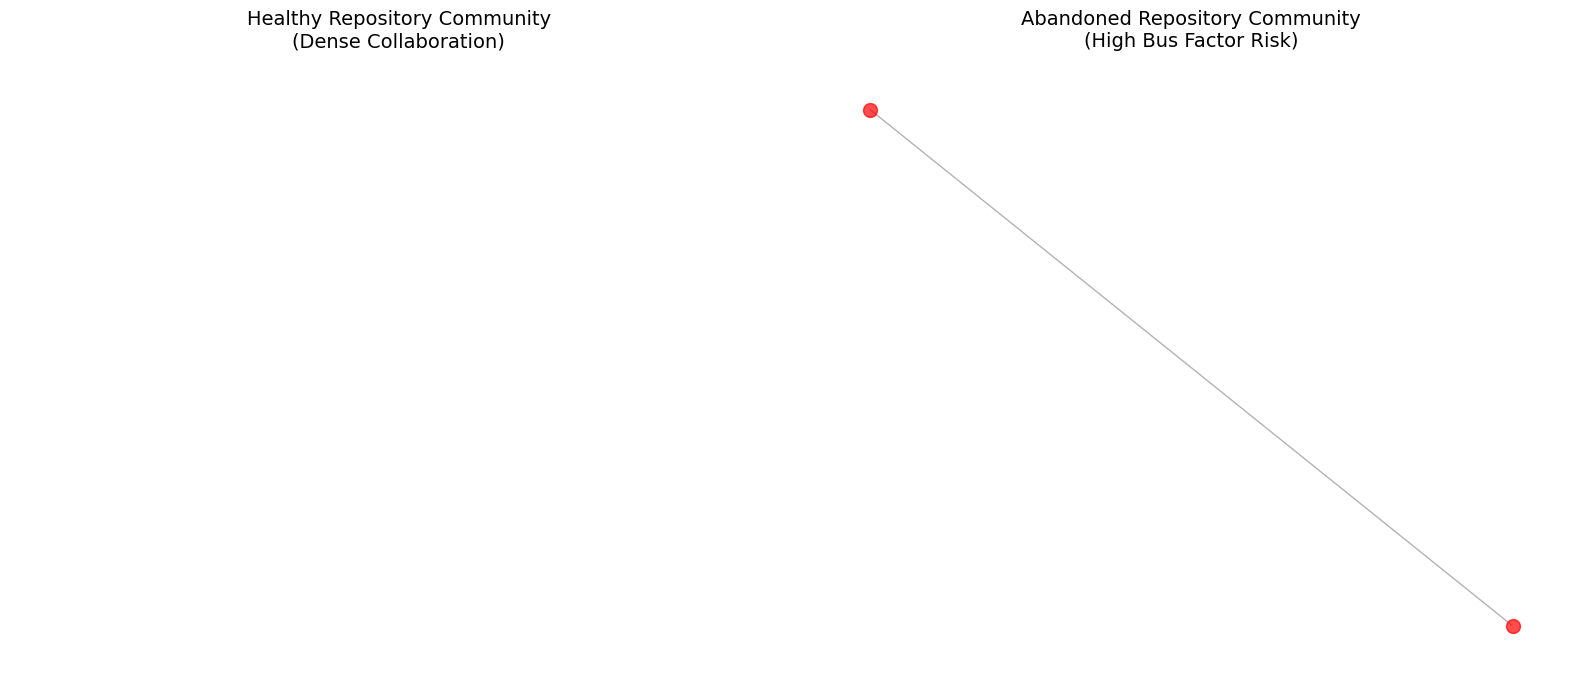

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings('ignore') # Hides matplotlib warnings

print("Loading raw events for Graph Mining...")
df_events = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/final_raw_dataset.parquet')
df_targets = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/target_repositories.parquet')

# 1. Create a "Date" column to track daily collaboration
df_events['date'] = pd.to_datetime(df_events['created_at']).dt.date

# 2. Define the Graph Builder Function
def build_collaboration_graph(df_repo_events):
    G = nx.Graph()
    devs = df_repo_events['actor_name'].unique()
    G.add_nodes_from(devs)

    # Link developers who worked on the same day
    for date, group in df_repo_events.groupby('date'):
        active_devs_today = group['actor_name'].unique()
        if len(active_devs_today) > 1:
            for u, v in combinations(active_devs_today, 2):
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)
    return G

# 3. Calculate "Bus Factor Risk" for all repositories
print("Extracting Network Metrics for 2,000 repositories")
graph_metrics = []

for repo_name, group in df_events.groupby('repo_name'):
    G = build_collaboration_graph(group)

    # Calculate Degree Centrality (Who is the most connected?)
    centrality = nx.degree_centrality(G)

    if len(centrality) == 0:
        bus_factor_risk = 1.0
    elif len(centrality) == 1:
        bus_factor_risk = 1.0 # Only one developer exists
    else:
        # Risk = The dominance of the single most central developer
        max_centrality = max(centrality.values())
        sum_centrality = sum(centrality.values())
        # Avoid division by zero
        bus_factor_risk = max_centrality / (sum_centrality + 1e-5)

    graph_metrics.append({
        'repo_name': repo_name,
        'bus_factor_risk': bus_factor_risk,
        'network_density': nx.density(G)
    })

df_graph_features = pd.DataFrame(graph_metrics)
print("Metrics extracted successfully!\n")

# --- VISUALIZATION DEMONSTRATION ---
print("Generating the Social Graph Visuals for your report...")

# Find one highly collaborative Active repo, and one solo Abandoned repo
active_repos = df_targets[df_targets['repo_status'] == 'Active']['repo_name'].tolist()
abandoned_repos = df_targets[df_targets['repo_status'] == 'Abandoned']['repo_name'].tolist()

# Select specific repos to draw (grabbing the first ones with decent event counts)
healthy_repo_data = df_events[df_events['repo_name'] == active_repos[2]]
dying_repo_data = df_events[df_events['repo_name'] == abandoned_repos[0]]

G_healthy = build_collaboration_graph(healthy_repo_data)
G_dying = build_collaboration_graph(dying_repo_data)

# Set up the side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot the Healthy Network
pos_healthy = nx.spring_layout(G_healthy, k=0.5)
nx.draw_networkx_nodes(G_healthy, pos_healthy, ax=ax1, node_size=100, node_color='green', alpha=0.7)
nx.draw_networkx_edges(G_healthy, pos_healthy, ax=ax1, alpha=0.3)
ax1.set_title(f"Healthy Repository Community\n(Dense Collaboration)", fontsize=14)
ax1.axis('off')

# Plot the Dying Network
pos_dying = nx.spring_layout(G_dying, k=0.5)
nx.draw_networkx_nodes(G_dying, pos_dying, ax=ax2, node_size=100, node_color='red', alpha=0.7)
nx.draw_networkx_edges(G_dying, pos_dying, ax=ax2, alpha=0.3)
ax2.set_title(f"Abandoned Repository Community\n(High Bus Factor Risk)", fontsize=14)
ax2.axis('off')

plt.tight_layout()
plt.show()

# Save the metrics to Drive so we can use them in the Random Forest
metrics_path = '/content/drive/MyDrive/DataMiningProject/graph_metrics.parquet'
df_graph_features.to_parquet(metrics_path, index=False)

Selected Healthy Model: MinaProtocol/mina
Selected Abandoned Model: segmen32ssstum/asd6


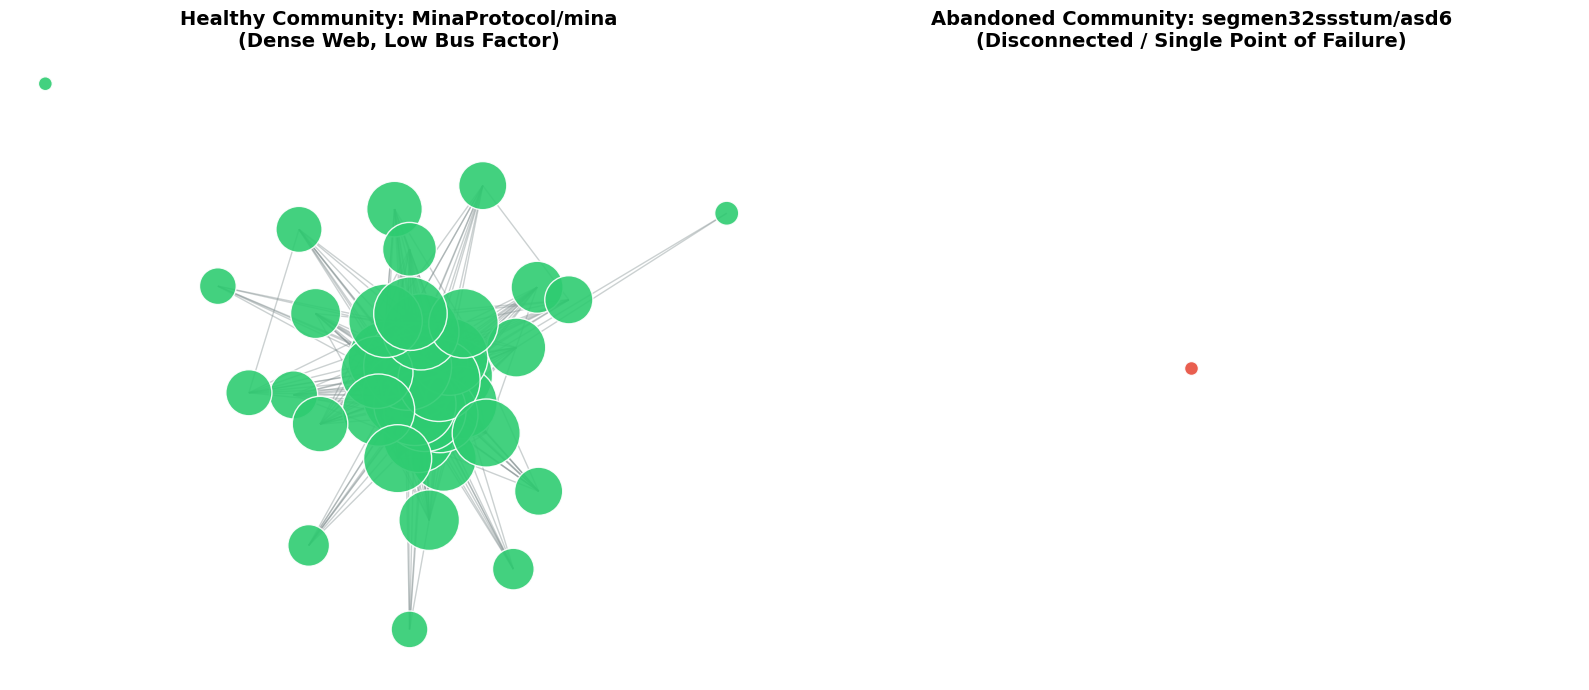

In [ ]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')


# Load our datasets (assuming they are saved from the previous steps)
df_events = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/final_raw_dataset.parquet')
df_targets = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/target_repositories.parquet')
df_graph_features = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/graph_metrics.parquet')

# 1. Find the busiest repositories to ensure we have rich, complex graphs
event_counts = df_events['repo_name'].value_counts().reset_index()
event_counts.columns = ['repo_name', 'event_count']

# Combine all our intelligence into one table
df_smart_search = pd.merge(df_graph_features, df_targets[['repo_name', 'repo_status']], on='repo_name')
df_smart_search = pd.merge(df_smart_search, event_counts, on='repo_name')

# 2. Pick the Ultimate Healthy Repo: Active, highly active (>50 events), and low bus factor (distributed teamwork)
best_healthy_repo = df_smart_search[
    (df_smart_search['repo_status'] == 'Active') &
    (df_smart_search['bus_factor_risk'] < 0.5) &
    (df_smart_search['network_density'] > 0)
].sort_values(by='event_count', ascending=False).iloc[0]['repo_name']

# 3. Pick the Ultimate Abandoned Repo: Abandoned, highly active, but a Bus Factor of 1.0 (One person doing everything)
best_dying_repo = df_smart_search[
    (df_smart_search['repo_status'] == 'Abandoned') &
    (df_smart_search['bus_factor_risk'] == 1.0) &
    (df_smart_search['event_count'] > 20)
].sort_values(by='event_count', ascending=False).iloc[0]['repo_name']

print(f"Selected Healthy Model: {best_healthy_repo}")
print(f"Selected Abandoned Model: {best_dying_repo}")

# --- Helper function to rebuild the specific graph ---
def build_collaboration_graph(df_repo_events):
    G = nx.Graph()
    devs = df_repo_events['actor_name'].unique()
    G.add_nodes_from(devs)

    df_repo_events['date'] = pd.to_datetime(df_repo_events['created_at']).dt.date
    for date, group in df_repo_events.groupby('date'):
        active_devs_today = group['actor_name'].unique()
        if len(active_devs_today) > 1:
            for u, v in combinations(active_devs_today, 2):
                if G.has_edge(u, v):
                    G[u][v]['weight'] += 1
                else:
                    G.add_edge(u, v, weight=1)
    return G

# Extract the data for our two heroes
G_healthy = build_collaboration_graph(df_events[df_events['repo_name'] == best_healthy_repo].copy())
G_dying = build_collaboration_graph(df_events[df_events['repo_name'] == best_dying_repo].copy())

# --- DRAWING THE VISUALS ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))

# Plot Healthy (Green Web)
pos_healthy = nx.spring_layout(G_healthy, k=0.8, iterations=50)
# Make node size proportional to their connections (degree)
d_healthy = dict(G_healthy.degree)
nx.draw_networkx_nodes(G_healthy, pos_healthy, ax=ax1, node_size=[(v+1)*100 for v in d_healthy.values()], node_color='#2ecc71', alpha=0.9, edgecolors='white')
nx.draw_networkx_edges(G_healthy, pos_healthy, ax=ax1, alpha=0.4, edge_color='#7f8c8d')
ax1.set_title(f"Healthy Community: {best_healthy_repo}\n(Dense Web, Low Bus Factor)", fontsize=14, fontweight='bold')
ax1.axis('off')

# Plot Dying (Red Star/Dots)
pos_dying = nx.spring_layout(G_dying, k=0.8, iterations=50)
d_dying = dict(G_dying.degree)
nx.draw_networkx_nodes(G_dying, pos_dying, ax=ax2, node_size=[(v+1)*100 for v in d_dying.values()], node_color='#e74c3c', alpha=0.9, edgecolors='white')
nx.draw_networkx_edges(G_dying, pos_dying, ax=ax2, alpha=0.4, edge_color='#7f8c8d')
ax2.set_title(f"Abandoned Community: {best_dying_repo}\n(Disconnected / Single Point of Failure)", fontsize=14, fontweight='bold')
ax2.axis('off')

plt.tight_layout()
plt.show()

Step 1: Loading and Merging Engineered Features...
Step 2: Defining Features (X) and Target (y)...
Step 3: Splitting data into Training (80%) and Testing (20%)...
Training on 983 repositories, validating on 246...
Step 4: Training the Random Forest Classifier...
Step 5: Evaluating Model Performance...

--- FINAL ACCURACY: 75.61% ---

Classification Report:
               precision    recall  f1-score   support

   Active (0)       0.71      0.68      0.69        99
Abandoned (1)       0.79      0.81      0.80       147

     accuracy                           0.76       246
    macro avg       0.75      0.74      0.74       246
 weighted avg       0.75      0.76      0.76       246



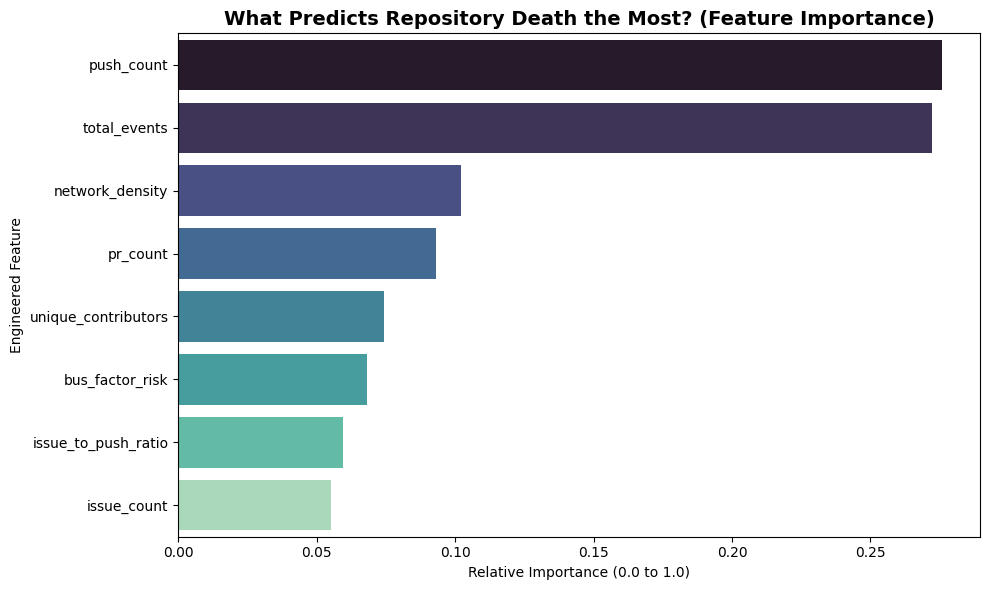


Step 6: Saving the Trained Model...
✅ Success! Model saved safely to: /content/drive/MyDrive/DataMiningProject/final_health_model.pkl


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import joblib

print("Step 1: Loading and Merging Engineered Features...")
df_basic = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/model_training_data.parquet')
df_graph = pd.read_parquet('/content/drive/MyDrive/DataMiningProject/graph_metrics.parquet')

# Merge the standard metrics with the graph metrics
df_final = pd.merge(df_basic, df_graph, on='repo_name', how='inner')

print("Step 2: Defining Features (X) and Target (y)...")
# We drop the sequence list and the repo name, keeping only the mathematical features
features = [
    'total_events', 'unique_contributors', 'push_count',
    'issue_count', 'pr_count', 'issue_to_push_ratio',
    'bus_factor_risk', 'network_density'
]

X = df_final[features]
y = df_final['is_abandoned']

print("Step 3: Splitting data into Training (80%) and Testing (20%)...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training on {len(X_train)} repositories, validating on {len(X_test)}...")

print("Step 4: Training the Random Forest Classifier...")
# We use class_weight='balanced' to handle any slight imbalances in the dataset
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', max_depth=10)
rf_model.fit(X_train, y_train)

print("Step 5: Evaluating Model Performance...\n")
y_pred = rf_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"--- FINAL ACCURACY: {accuracy * 100:.2f}% ---\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Active (0)', 'Abandoned (1)']))

# --- GENERATE THE FEATURE IMPORTANCE CHART ---
feature_importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='mako')
plt.title('What Predicts Repository Death the Most? (Feature Importance)', fontsize=14, fontweight='bold')
plt.xlabel('Relative Importance (0.0 to 1.0)')
plt.ylabel('Engineered Feature')
plt.tight_layout()
plt.show()

print("\nStep 6: Saving the Trained Model...")
model_path = '/content/drive/MyDrive/DataMiningProject/final_health_model.pkl'
joblib.dump(rf_model, model_path)
print(f"✅ Success! Model saved safely to: {model_path}")